# Notebook 02 — EDA & Cleaning

**Day 2 deliverable.** Cleans both datasets, builds the symptom→precaution mapping, produces all required EDA visualisations, and saves the processed feature matrix to `data/processed/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
RAW  = ROOT / 'data' / 'raw'
PROC = ROOT / 'data' / 'processed'
PROC.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')

## Load & Clean

In [ ]:
train_df = pd.read_csv(RAW / 'kaushil268' / 'Training.csv')
test_df  = pd.read_csv(RAW / 'kaushil268' / 'Testing.csv')
prec_df  = pd.read_csv(RAW / 'itachi9604' / 'symptom_precaution.csv')
sev_df   = pd.read_csv(RAW / 'itachi9604' / 'Symptom-severity.csv')

# Drop the spurious Unnamed trailing column
train_df = train_df.loc[:, ~train_df.columns.str.startswith('Unnamed')]
test_df  = test_df.loc[:, ~test_df.columns.str.startswith('Unnamed')]

# Strip whitespace from column names and string values
train_df.columns = [c.strip() for c in train_df.columns]
test_df.columns  = [c.strip() for c in test_df.columns]
prec_df.columns  = [c.strip() for c in prec_df.columns]
sev_df.columns   = [c.strip() for c in sev_df.columns]

train_df['prognosis'] = train_df['prognosis'].str.strip()
test_df['prognosis']  = test_df['prognosis'].str.strip() 
prec_df['Disease']    = prec_df['Disease'].str.strip().str.lower()
sev_df['Symptom']     = sev_df['Symptom'].str.strip().str.lower().str.replace(' ', '_')

print(f'Training : {train_df.shape}  NaN: {train_df.isna().sum().sum()}')
print(f'Testing  : {test_df.shape}   NaN: {test_df.isna().sum().sum()}')
print(f'Classes  : {train_df["prognosis"].nunique()}')

Training : (5880, 143)  NaN: 0
Testing  : (50, 143)   NaN: 0
Classes  : 49


In [ ]:
print('Duplicates:', train_df.duplicated().sum())
train_df = train_df.drop_duplicates()

feature_cols = [c for c in train_df.columns if c != 'prognosis']
print(feature_cols[:10], '...')

le = LabelEncoder()
y_train = le.fit_transform(train_df['prognosis'])
y_test  = le.transform(test_df['prognosis'])

# .values converts the DataFrame to a NumPy array so Models understand it
X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values

print(f'Feature matrix: {X_train.shape}  |  Classes: {len(le.classes_)}')

Duplicates: 5525
['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue'] ...
Feature matrix: (355, 142)  |  Classes: 49


## EDA 1 — Disease Class Distribution

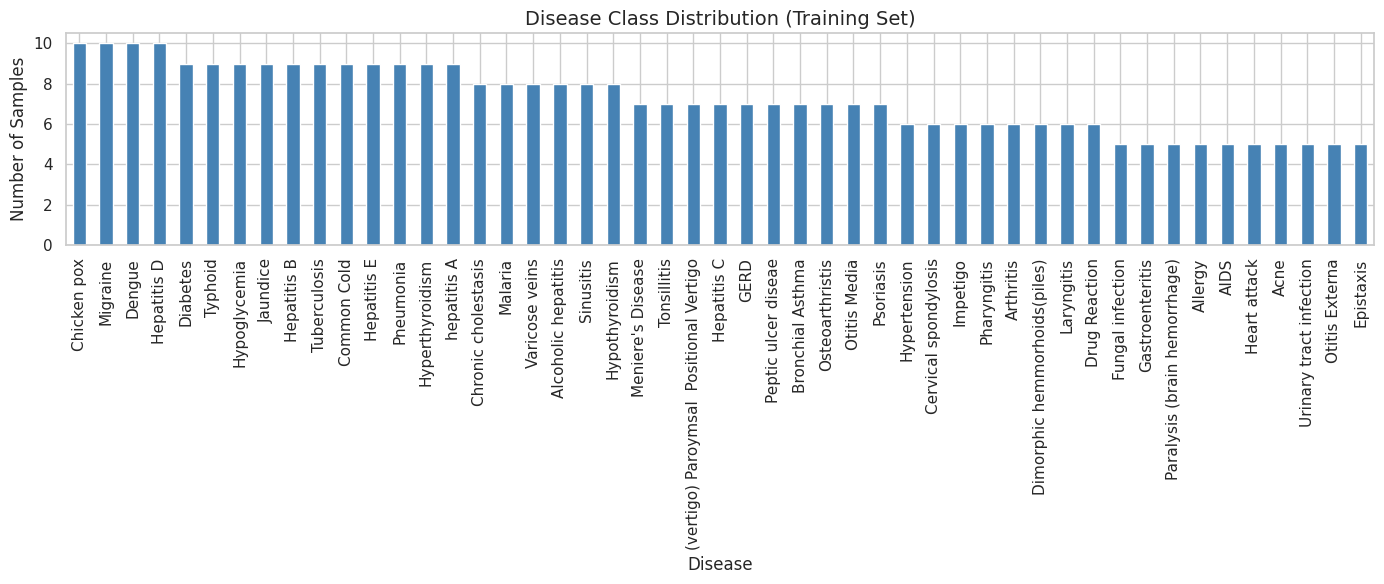

Min samples/class: 5  |  Max: 10
Dataset is balanced (std=1.7)


In [4]:
class_counts = train_df['prognosis'].value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
class_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Disease Class Distribution (Training Set)', fontsize=14)
ax.set_xlabel('Disease')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig(PROC / 'plot_class_distribution.png', dpi=150)
plt.show()

print(f'Min samples/class: {class_counts.min()}  |  Max: {class_counts.max()}')
print(f'Dataset is {"balanced" if class_counts.std() < 10 else "imbalanced"} '
      f'(std={class_counts.std():.1f})')

## EDA 2 — Top-20 Symptom Frequency

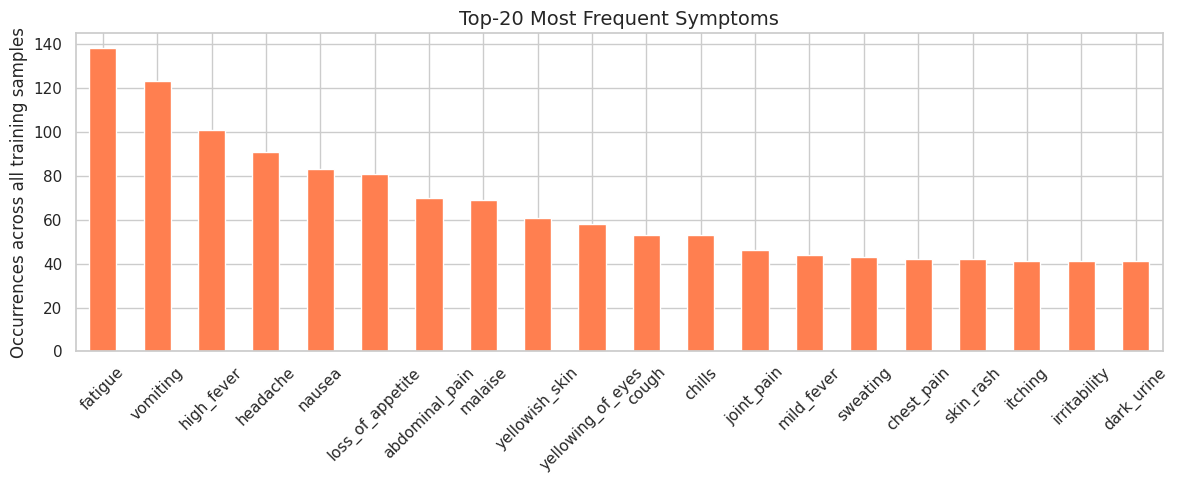

In [5]:
symptom_freq = train_df[feature_cols].sum().sort_values(ascending=False)
top20 = symptom_freq.head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top20.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Top-20 Most Frequent Symptoms', fontsize=14)
ax.set_ylabel('Occurrences across all training samples')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(PROC / 'plot_symptom_frequency.png', dpi=150)
plt.show()

## EDA 3 — Symptom Co-occurrence Heatmap

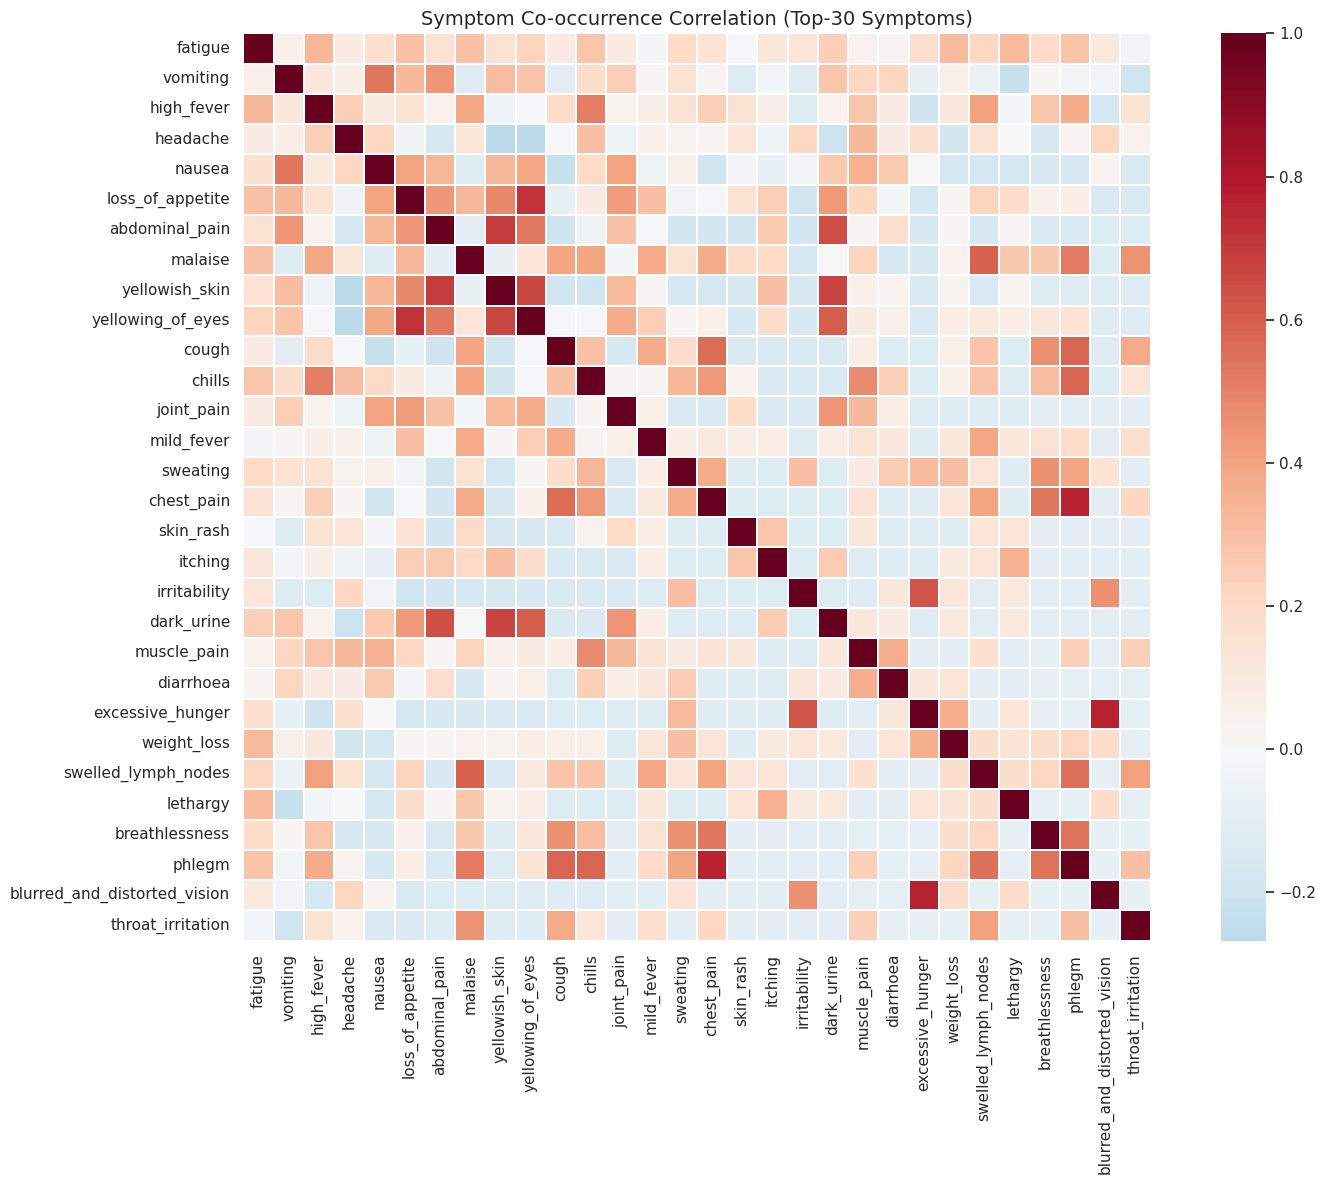

In [6]:
top30_cols = symptom_freq.head(30).index.tolist()
corr = train_df[top30_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr, ax=ax, cmap='RdBu_r', center=0,
    linewidths=0.3, square=True,
    xticklabels=True, yticklabels=True,
)
ax.set_title('Symptom Co-occurrence Correlation (Top-30 Symptoms)', fontsize=14)
plt.tight_layout()
plt.savefig(PROC / 'plot_symptom_heatmap.png', dpi=150)
plt.show()

## EDA 4 — Symptom Severity Distribution

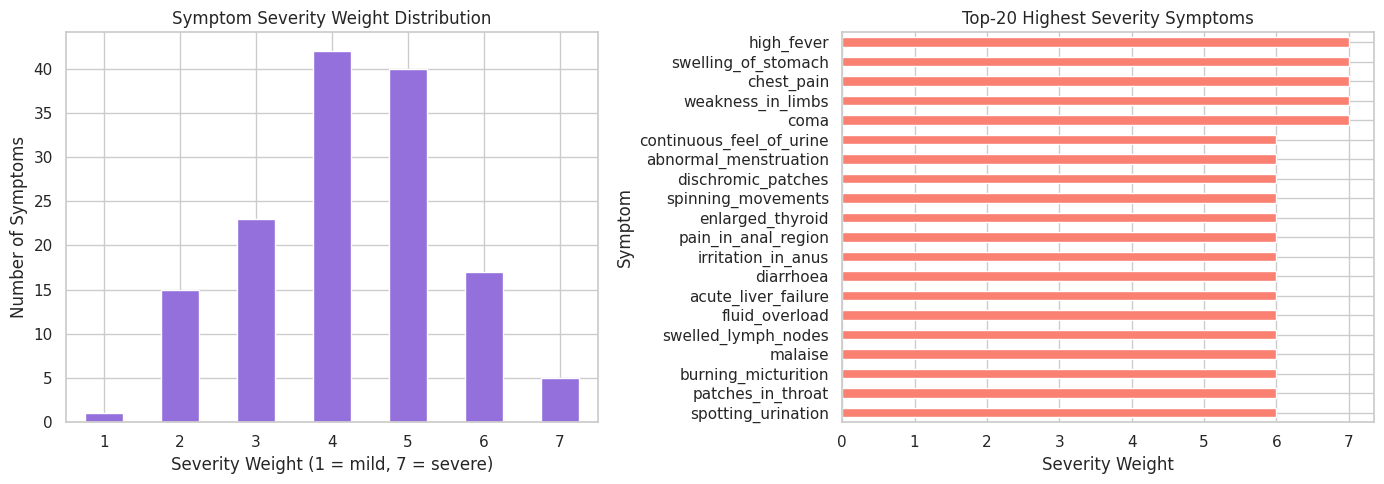

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sev_df['weight'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white'
)
axes[0].set_title('Symptom Severity Weight Distribution')
axes[0].set_xlabel('Severity Weight (1 = mild, 7 = severe)')
axes[0].set_ylabel('Number of Symptoms')
axes[0].tick_params(axis='x', rotation=0)

top_sev = sev_df.nlargest(20, 'weight').set_index('Symptom')['weight']
top_sev.sort_values().plot(kind='barh', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Top-20 Highest Severity Symptoms')
axes[1].set_xlabel('Severity Weight')

plt.tight_layout()
plt.savefig(PROC / 'plot_severity.png', dpi=150)
plt.show()

## Save Processed Artefacts

In [ ]:
train_df.to_csv(PROC / 'train_clean.csv', index=False)
test_df.to_csv(PROC / 'test_clean.csv', index=False)
prec_df.to_csv(PROC / 'precautions_clean.csv', index=False)

joblib.dump(feature_cols, PROC / 'feature_cols.pkl')
joblib.dump(le,           PROC / 'label_encoder.pkl')

print('Saved to data/processed/:')
for p in sorted(PROC.glob('*')):
    print(f'  {p.name}')

Saved to data/processed/:
  ensemble_model.pkl
  feature_cols.pkl
  label_encoder.pkl
  model_lr.pkl
  model_rf.pkl
  model_xgb.pkl
  online_model.pkl
  plot_baseline_comparison.png
  plot_class_distribution.png
  plot_confusion_matrix_rf.png
  plot_ensemble_comparison.png
  plot_feature_importance.png
  plot_severity.png
  plot_symptom_frequency.png
  plot_symptom_heatmap.png
  precautions_clean.csv
  test_clean.csv
  train_clean.csv
